# Анализ оттока клиентов

***Цель исследования:*** на основании анализа оттока клиентов определить признаки отточности и выделить сегменты клиентов для повышения эффективности работы банка с клиентами и как следствие увеличения доходов банка.

***Описание данных***


Датасет /datasets/bank_scrooge.csv содержит данные о клиентах банка «Метанпром». Банк располагается в
Ярославле и областных городах: Ростов Великий и Рыбинск.

Колонки:
 - USERID — идентификатор пользователя,
 - score — баллы кредитного скоринга,
 - city — город,
 - gender — пол,
 - age — возраст,
 - equity — количество баллов собственности
 - balance — баланс на счёте,
 - products — количество продуктов, которыми пользуется клиент,
 - credit_card — есть ли кредитная карта,
 - last_activity — активный клиент,
 - EST_SALARY — оценочный доход клиента,
 - сhurn — признак оттока.

## Загрузка и описание данных

In [244]:
pip install phik

Note: you may need to restart the kernel to use updated packages.


In [245]:
# импортируем необходимые библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import phik
from phik import resources, report
import statistics as st
from statistics import mode
import numpy as np
from scipy import stats as st

In [246]:
# выгружаем данные в переменную data
data = pd.read_csv('/datasets/bank_scrooge.csv')

data.head() #отобразим первые пять строк датафрейма

,USERID,score,city,gender,age,equity,balance,products,credit_card,last_activity,EST_SALARY,churn
0,183012,850.0,Рыбинск,Ж,25.0,1,59214.82,2,0,1,75719.14,1
1,146556,861.0,Рыбинск,Ж,37.0,5,850594.33,3,1,0,86621.77,0
2,120722,892.0,Рыбинск,Ж,30.0,0,NaN,1,1,1,107683.34,0
3,225363,866.0,Ярославль,Ж,51.0,5,1524746.26,2,0,1,174423.53,1
4,157978,730.0,Ярославль,М,34.0,5,174.00,1,1,0,67353.16,1


Наименования столбцов имеют разные регистры, на этапе предобработки приведем все наименования к единому стилю.

In [247]:
# рассмотрим основную информацию о датафрейме
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   USERID         10000 non-null  int64  
 1   score          10000 non-null  float64
 2   city           10000 non-null  object 
 3   gender         10000 non-null  object 
 4   age            9974 non-null   float64
 5   equity         10000 non-null  int64  
 6   balance        7705 non-null   float64
 7   products       10000 non-null  int64  
 8   credit_card    10000 non-null  int64  
 9   last_activity  10000 non-null  int64  
 10  EST_SALARY     10000 non-null  float64
 11  churn          10000 non-null  int64  
dtypes: float64(4), int64(6), object(2)
memory usage: 937.6+ KB


Датафрейм содержит 12 столбцов и 1000 строк. В столбцах age и balance наблюдаются пропуски. 

## Предобработка данных

### Приведение данных к единому стилю

На предыдущем этапе, было выяснено, что наименования столбцов имеют разный вид. Приведем их к единому стилю - к нижнему регистру. 

In [248]:
# приводим наименования к нижнему регистру
data.columns = data.columns.str.lower()

data.columns  # проверим наименования после преобразований

Index(['userid', 'score', 'city', 'gender', 'age', 'equity', 'balance',
       'products', 'credit_card', 'last_activity', 'est_salary', 'churn'],
      dtype='object')

Названия приведены к общему стилю

### Типы данных

In [249]:
# рассмотрим типы данных в столбцах
data.dtypes

userid             int64
score            float64
city              object
gender            object
age              float64
equity             int64
balance          float64
products           int64
credit_card        int64
last_activity      int64
est_salary       float64
churn              int64
dtype: object

Проанализировав типы данных в столбцах, можно сказать, что нет необходимости их менять.

### Дубликаты

Проверим данные на наличие явных и неявных дубликатов

In [250]:
# проверка на наличие явных дубликатов
data.duplicated().sum()

0

Явные дубликаты не выявлены. Проверим есть ли неявные дубликаты. Во всех столбцах, кроме userid, данные могут быть одинаковыми, поэтому проверим есть ли дубликаты по столбцу userid.

In [251]:
data['userid'].duplicated().sum()

73

В данных наблюдаются 73 строки дубликаты, рассмотрим их подробнее. Проверим сколько уникальных userid повторяется и чем отличаются строки с этими идентификаторами.

In [252]:
# найдем уникальные повторяющиеся userid
data.loc[data['userid'].duplicated()]['userid'].unique()

array([190253, 210662, 131419, 187635, 220816, 221156, 208081, 170312,
       185748, 211130, 217643, 226719, 197364, 155765, 126368, 218868,
       151662, 143592, 141265, 208815, 152479, 217619, 208738, 120258,
       188957, 228075, 172142, 163207, 210135, 219343, 164676, 214031,
       140377, 117943, 116540, 210792, 191520, 198635, 226550, 149365,
       216848, 148826, 206759, 210898, 227795, 210627, 221197, 123461,
       181526, 162053, 127440, 199312, 222480, 183510, 200863, 150667,
       202983, 155872, 187459, 217826, 141945, 129785, 160075, 185829,
       221809, 171751, 195884, 163657, 124450, 168998, 140934, 217412,
       175730])

Все 73 дубликата относятся к разным userid, можно предположить, что для каждого повторяющегося userid есть определенное различие по другим признакам. Рассмотрим несколько дубликатов.

In [253]:
# рассмотрим строки с пятью разными идентификаторами, имеющими дубликаты
display(data.loc[data['userid'] == 190253])

display(data.loc[data['userid'] == 163207])

display(data.loc[data['userid'] == 171751])

display(data.loc[data['userid'] == 210627])

display(data.loc[data['userid'] == 164676])

,userid,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn
231,190253,823.0,Рыбинск,М,37.0,4,373348.39,2,0,1,131947.92,1
1583,190253,726.0,Ярославль,М,49.0,0,NaN,1,1,1,177700.78,0


,userid,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn
3564,163207,853.0,Рыбинск,М,42.0,4,543839.62,1,1,1,105281.97,1
6786,163207,838.0,Ярославль,Ж,42.0,4,652776.60,2,1,1,97545.36,0


,userid,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn
4587,171751,874.0,Рыбинск,Ж,26.0,5,292054.42,2,0,1,20528.56,1
9653,171751,862.0,Ярославль,М,42.0,4,481992.19,2,1,0,71816.86,0


,userid,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn
7453,210627,864.0,Ярославль,Ж,38.0,4,1527225.32,4,1,1,162999.17,1
8521,210627,804.0,Рыбинск,М,30.0,2,347818.88,3,1,0,129015.25,0


,userid,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn
58,164676,860.0,Ярославль,М,37.0,5,648594.03,2,1,1,213586.86,1
7271,164676,790.0,Рыбинск,Ж,77.0,1,111202.01,1,1,0,32835.45,0


Можно заметить, что все рассмотренные клиенты являются клиентами отделений банка в Ярославле и Рыбинске, при этом, судя по значениям признаков, это разные клиенты. Можно предположить, что возникла техническая ошибка во время присвоения уникального номера клиентам в указанных отделениях банка из-за чего базы данных этих отделений пересеклись.

Так как клиенты скорее всего разные, оставим эти дубликаты без обработки.

### Пропуски

Посчитаем количество пропусков в столбцах датафрейма и рассмотрим возможные способы их заполнения (при необходимости)

In [254]:
data.isna().sum()

userid              0
score               0
city                0
gender              0
age                26
equity              0
balance          2295
products            0
credit_card         0
last_activity       0
est_salary          0
churn               0
dtype: int64

Пропуски наблюдаются в столбцах 'age' и 'balance'. Рассмотрим есть ли признаки связанные с данными признаками.

In [255]:
data['age_na'] = data['age'].apply(lambda x: 1 if pd.isna(x) else 0)

In [256]:
# с помощью корреляции Phi_K рассмотрим, что влияет на пропуски в столбце с балансом
data.drop('userid', axis=1).phik_matrix(interval_cols=['score', 'age', 'balance', 'est_salary']).style.background_gradient(cmap='YlOrRd')

,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn,age_na
score,1.000000,0.090984,0.071278,0.032750,0.527970,0.170897,0.309150,0.208683,0.052911,0.395681,0.229572,0.059585
city,0.090984,1.000000,0.012720,0.091769,0.063431,0.039968,0.222573,0.074831,0.030531,0.171390,0.016811,0.011859
gender,0.071278,0.012720,1.000000,0.286450,0.064554,0.045424,0.122547,0.196238,0.014156,0.144801,0.218799,0.000000
age,0.032750,0.091769,0.286450,1.000000,0.046514,0.019169,0.133230,0.157632,0.090068,0.359738,0.191653,nan
equity,0.527970,0.063431,0.064554,0.046514,1.000000,0.000000,0.442391,0.221940,0.051091,0.286489,0.352726,0.038201
balance,0.170897,0.039968,0.045424,0.019169,0.000000,1.000000,0.000000,0.000000,0.000000,0.374374,0.024701,0.000000
products,0.309150,0.222573,0.122547,0.133230,0.442391,0.000000,1.000000,0.459214,0.191403,0.157906,0.441363,0.044816
credit_card,0.208683,0.074831,0.196238,0.157632,0.221940,0.000000,0.459214,1.000000,0.049761,0.038195,0.202997,0.000000
last_activity,0.052911,0.030531,0.014156,0.090068,0.051091,0.000000,0.191403,0.049761,1.000000,0.046097,0.261174,0.032798
est_salary,0.395681,0.171390,0.144801,0.359738,0.286489,0.374374,0.157906,0.038195,0.046097,1.000000,0.047661,0.009403


В соответствии с полученными коэффициентами корреляции нет признаков, с которыми бы признак age достаточно сильно коррелировал. То есть пропуски в данном столбце случайные и их можно классифицировать как MCAR. Так как пропусков в столбце age немного (0,26%), удалим их. 

Пропусков в столбце с балансом на счете клиента достаточно много - почти 23%, рассмотрим их подробнее.

In [257]:
# удаляем пропуски в столбце 'age'
data = data.dropna(subset=['age'])

Для более подробного рассмотрения пропусков в столбце 'balance' создадим переменную, содержащую id пользователей, у которых отсутствует какое-либо значения баланса на счете. Затем добавим в датафрейм новый столбец с признаком наличия пропуска: 1-пропуск,  0-значение есть. С помощью нового столбца выясним, зависят ли пропуски от какого-то признака или нет.

In [258]:
data['balance_na'] = data['balance'].apply(lambda x: 1 if pd.isna(x) else 0)

In [259]:
data.head()

,userid,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn,age_na,balance_na
0,183012,850.0,Рыбинск,Ж,25.0,1,59214.82,2,0,1,75719.14,1,0,0
1,146556,861.0,Рыбинск,Ж,37.0,5,850594.33,3,1,0,86621.77,0,0,0
2,120722,892.0,Рыбинск,Ж,30.0,0,NaN,1,1,1,107683.34,0,0,1
3,225363,866.0,Ярославль,Ж,51.0,5,1524746.26,2,0,1,174423.53,1,0,0
4,157978,730.0,Ярославль,М,34.0,5,174.00,1,1,0,67353.16,1,0,0


In [260]:
# с помощью корреляции Phi_K рассмотрим, что влияет на пропуски в столбце с балансом
data.drop('userid', axis=1).phik_matrix(interval_cols=['score', 'age', 'balance', 'est_salary']).style.background_gradient(cmap='YlOrRd')

/opt/conda/lib/python3.9/site-packages/phik/data_quality.py:82: UserWarning: Not enough unique value for variable age_na for analysis 1. Dropping this column
  warnings.warn(


,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn,balance_na
score,1.000000,0.090564,0.070361,0.032750,0.527316,0.170884,0.308312,0.208120,0.051763,0.394935,0.229475,0.754146
city,0.090564,1.000000,0.011924,0.091769,0.062559,0.039931,0.223196,0.074660,0.030399,0.170881,0.016431,0.039951
gender,0.070361,0.011924,1.000000,0.286450,0.063699,0.045434,0.122023,0.195831,0.012733,0.144177,0.219731,0.096927
age,0.032750,0.091769,0.286450,1.000000,0.046514,0.019169,0.133230,0.157632,0.090068,0.359738,0.191653,0.047756
equity,0.527316,0.062559,0.063699,0.046514,1.000000,0.000000,0.441413,0.221467,0.051218,0.285580,0.352103,0.975565
balance,0.170884,0.039931,0.045434,0.019169,0.000000,1.000000,0.000000,0.000000,0.000000,0.374367,0.024672,nan
products,0.308312,0.223196,0.122023,0.133230,0.441413,0.000000,1.000000,0.459117,0.191921,0.157374,0.440923,0.791714
credit_card,0.208120,0.074660,0.195831,0.157632,0.221467,0.000000,0.459117,1.000000,0.049306,0.038441,0.202374,0.244231
last_activity,0.051763,0.030399,0.012733,0.090068,0.051218,0.000000,0.191921,0.049306,1.000000,0.044857,0.262164,0.041335
est_salary,0.394935,0.170881,0.144177,0.359738,0.285580,0.374367,0.157374,0.038441,0.044857,1.000000,0.048829,0.429668


Согласно полученным коэффициентам корреляции phi_k достаточно сильная связь между отсутствием данных о балансе на счете наблюдается у признаков 'score', 'equity' и 'products'. Данные пропуски можно отнести к к типу MNAR Таким образом, логически заполнить пропуске в столбце с балансами  на основании имеющихся данных невозможно, поэтому оставим этот столбец без изменений.

## EDA

### Аномальные значения

Проверим данные на наличие аномальных значений, чтобы в дальнейшем анализе применять к ним подходящие агрегирующие функции.

In [261]:
data.describe()

,userid,score,age,equity,balance,products,credit_card,last_activity,est_salary,churn,age_na,balance_na
count,9974.000000,9974.000000,9974.000000,9974.000000,7.695000e+03,9974.000000,9974.000000,9974.000000,9.974000e+03,9974.000000,9974.0,9974.000000
mean,171755.218669,848.682575,42.734409,2.630840,8.272456e+05,1.871466,0.680168,0.522859,1.477868e+05,0.182374,0.0,0.228494
std,33695.527126,65.399720,12.179971,1.979965,1.980327e+06,0.792729,0.466435,0.499502,1.392855e+05,0.386172,0.0,0.419884
min,94561.000000,642.000000,18.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,2.546300e+03,0.000000,0.0,0.000000
25%,142760.000000,802.000000,33.000000,0.000000,2.956987e+05,1.000000,0.000000,0.000000,7.525166e+04,0.000000,0.0,0.000000
50%,172643.000000,853.000000,40.000000,3.000000,5.242953e+05,2.000000,1.000000,1.000000,1.196268e+05,0.000000,0.0,0.000000
75%,201163.750000,900.000000,51.000000,4.000000,9.800512e+05,2.000000,1.000000,1.000000,1.744998e+05,0.000000,0.0,0.000000
max,229145.000000,1000.000000,86.000000,9.000000,1.191136e+08,5.000000,1.000000,1.000000,1.395064e+06,1.000000,0.0,1.000000


В столбцах 'balance' и 'est_salary' наблюдается большая разница между средним и медианным значением. Рассмотрим гистограммы распределения по всем признакам, кроме userid.

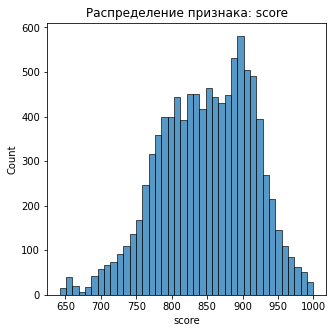

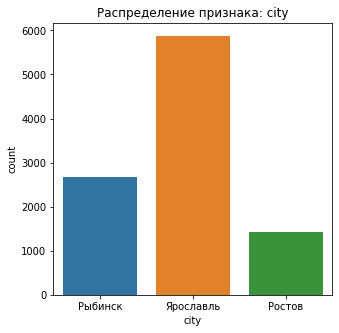

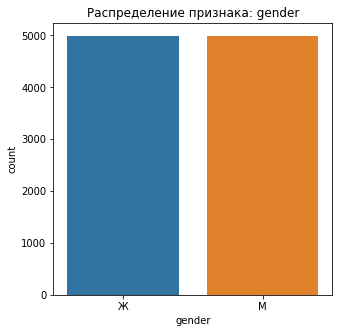

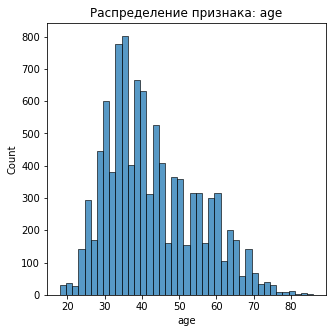

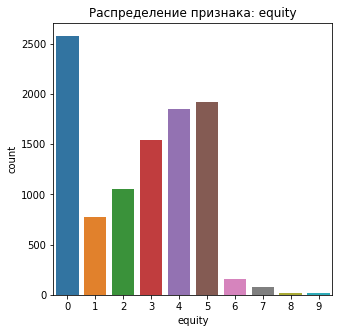

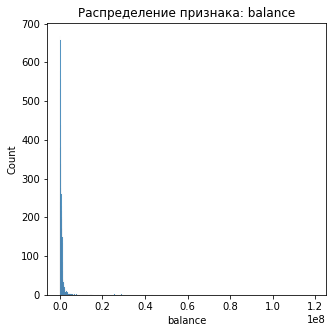

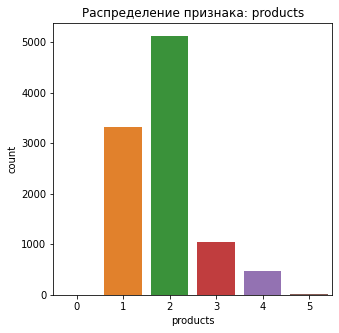

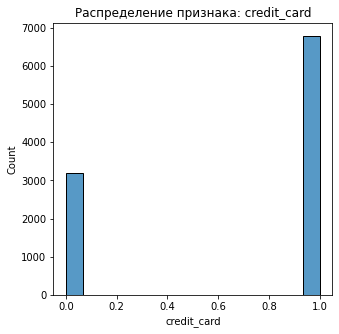

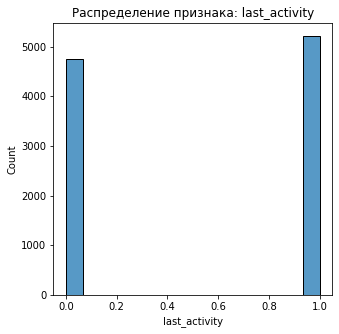

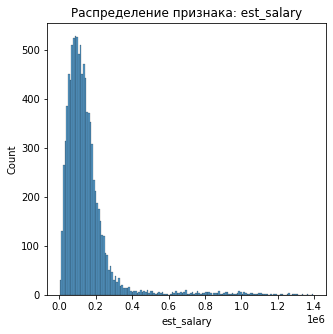

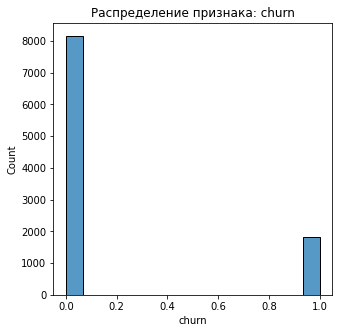

In [262]:
# создадим список наименований столбцов с признаками
data_columns = data.drop(['userid', 'balance_na', 'age_na'], axis=1).columns

# напишем функцию для построения гистограмм в разрезе факта оттока
def show_plot(df, column_name):
    """Данная функция строит гистограммы распределения признаков.
    
    Функция принимает на вход датафрейм, наименование
    столбца-признака, распределение которого исследуется, 
    а также наименование столбца-признака, в разрезе которого будет 
    строиться гистограмма. Если признак col не указан, гистограмма строится без разреза.
    """
    plt.figure(figsize=(5, 5))
    
    if column_name in ['equity', 'products', 'city', 'gender']:
        sns.countplot(data=df, x=column_name)
        plt.title('Распределение признака: {}'.format(column_name))
        plt.show()
        
    else:
        sns.histplot(df, x=column_name)
        plt.title('Распределение признака: {}'.format(column_name))
        plt.show()
    
# с помощью цикла переберем все столбцы с признаками и построим графики
for column in data_columns:
    show_plot(data, column)

Можно заметить, что у нескольких признаков есть длинные "хвосты", что может свидетельствовать о наличии аномальных значений. Это признаки 'balance' и 'est_salary'. Рассмотрим диаграммы размаха этих признаков.

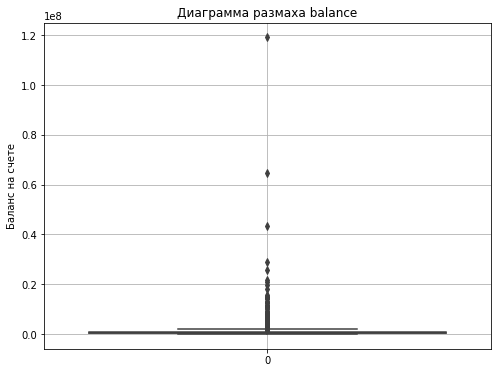

In [263]:
plt.figure(figsize = (8,6))

# построим "ящик с усами" по полученным данным
sns.boxplot(data=data['balance']);
plt.grid(True)
   
plt.title('Диаграмма размаха balance');
plt.ylabel('Баланс на счете');

На диаграмме размаха видны множество аномально больших значений, ящик с усами из-за этого практически сложился в одну линию. Укрупним диаграмму, чтобы медиана и квантили были видны.

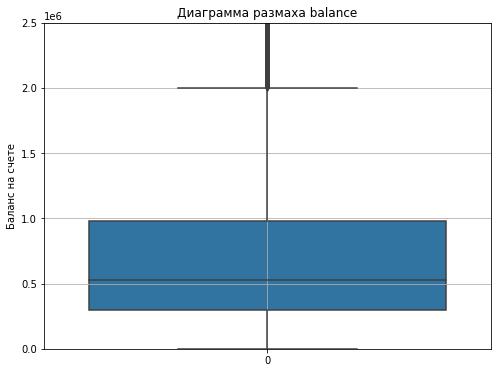

In [264]:
plt.figure(figsize = (8,6))

# построим "ящик с усами" по полученным данным
sns.boxplot(data=data['balance']);
plt.ylim(0, 2500000)
plt.grid(True)
   
plt.title('Диаграмма размаха balance');
plt.ylabel('Баланс на счете');

По графику можно сказать, что баланс свыше 2 млн. является аномальным.

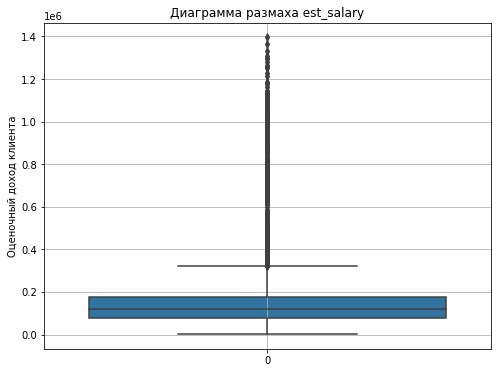

In [265]:
plt.figure(figsize = (8,6))

# построим "ящик с усами" по полученным данным
sns.boxplot(data=data['est_salary']);
plt.grid(True)
   
plt.title('Диаграмма размаха est_salary');
plt.ylabel('Оценочный доход клиента');

На диаграмме размаха оценочного дохода клиента также можно увидеть множество выбросов - аномально высокого дохода. Укрупним диаграмму, чтобы видеть все квантили.

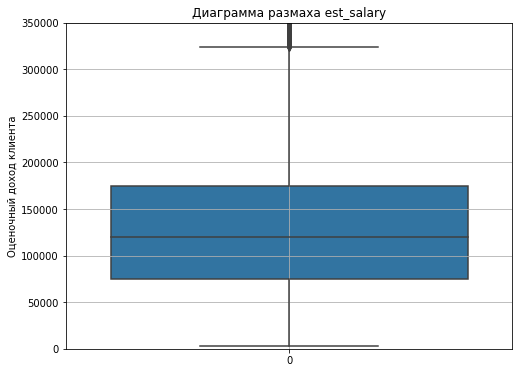

In [266]:
plt.figure(figsize = (8,6))

# построим "ящик с усами" по полученным данным
sns.boxplot(data=data['est_salary']);
plt.ylim(0,350000)
plt.grid(True)
   
plt.title('Диаграмма размаха est_salary');
plt.ylabel('Оценочный доход клиента');

По графику можно сказать, что доход свыше 325тыс.является аномальным.

### Средний уровень оттока по банку

Посчитаем уровень оттока по банку в целом. Так как в столбце 'churn' содержатся только 0 и 1, воспользуемся функцией mean, чтобы посчитать долю клиентов, попавших а отток.

In [267]:
# записываем в переменную уровень оттока
total_churn_level = data['churn'].mean()

total_churn_level

0.18237417284940846

В целом по банку уровень оттока составил 18.2%

### Анализ распределения признаков в разрезе оттока

Рассмотрим распределение признаков в разрезе оттока, чтобы выяснить, какие из нихя являются признаками отточности.

In [268]:
data_columns

Index(['score', 'city', 'gender', 'age', 'equity', 'balance', 'products',
       'credit_card', 'last_activity', 'est_salary', 'churn'],
      dtype='object')

#### Распределение score

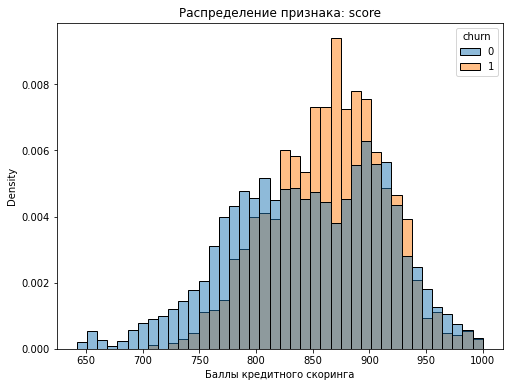

In [269]:
plt.figure(figsize=(8, 6))
sns.histplot(data,x='score', hue='churn',stat='density',common_norm=False)
plt.title('Распределение признака: score')
plt.xlabel('Баллы кредитного скоринга')
plt.show()

Отток клиентов наблюдается на промежутке значений от 700 до 1000 баллов кредитного скоринга, при этом наибольшее значение оттока можно увидеть на промежутке от 830 до 910 баллов, а так же в районе 930-940 баллов.

#### Распределение city

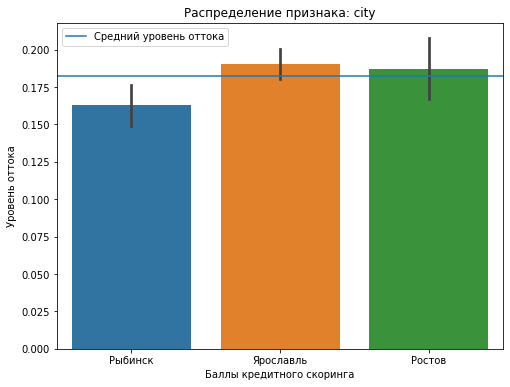

In [270]:
plt.figure(figsize=(8, 6))
sns.barplot(data=data, x='city', y='churn')
plt.axhline(total_churn_level, label='Средний уровень оттока')
plt.xlabel('Баллы кредитного скоринга')
plt.ylabel('Уровень оттока')
plt.legend()

plt.title('Распределение признака: city')
plt.show()

Уровень оттока в Ярославле и Ростове выше, чем средний уровень оттока по банку в целом.

#### Распределение age

In [271]:
display(data['age'].min())
display(data['age'].max())

18.0

86.0

Минимльный возраст клиентов-18 лет, максимальный 86. Построим гистограмму с корзиной размером в 5 лет.

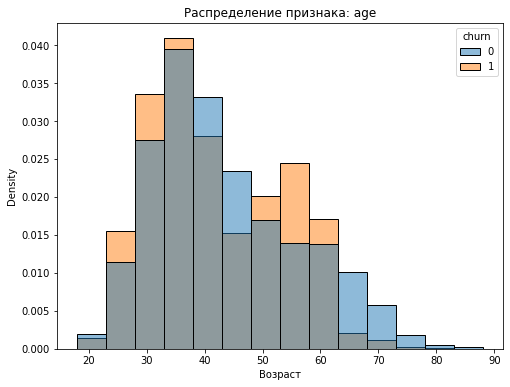

In [272]:
plt.figure(figsize=(8, 6))
binwidth = 5
sns.histplot(data,x='age', hue='churn', bins=np.arange(min(data['age']), max(data['age']) + binwidth, binwidth), stat='density', common_norm=False)
plt.xlabel('Возраст')
plt.title('Распределение признака: age')
plt.show()

Достаточно высокий уровень оттока наблюдается у клиентов в возрасте 26-34 года и 50-60 лет.

#### Распределение equity

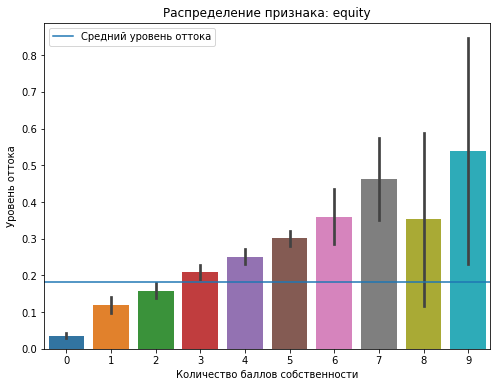

In [273]:
plt.figure(figsize=(8, 6))
sns.barplot(data=data, x='equity', y='churn')
plt.axhline(total_churn_level, label='Средний уровень оттока')
plt.xlabel('Количество баллов собственности')
plt.ylabel('Уровень оттока')
plt.legend()

plt.title('Распределение признака: equity')
plt.show()

У клиентов с количеством баллов собственности выше 2 достаточно высокий уровень оттока - выше, чем в среднем по банку. Наибольшая доля оттока наблюдается у клиентов с количеством баллов собственности равным 9, при этом отток у клиентов с 8 баллами собственности ниже, чем у клиентов с 7 баллами.

#### Распределение balance

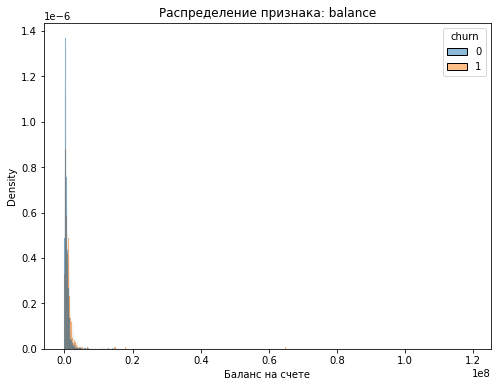

In [274]:
plt.figure(figsize=(8, 6))
sns.histplot(data,x='balance', hue='churn',stat="density", common_norm=False)
plt.xlabel('Баланс на счете')
plt.title('Распределение признака: balance')
plt.show()

Необходимо удалить выбросы, чтобы была возможность рассмотреть график.

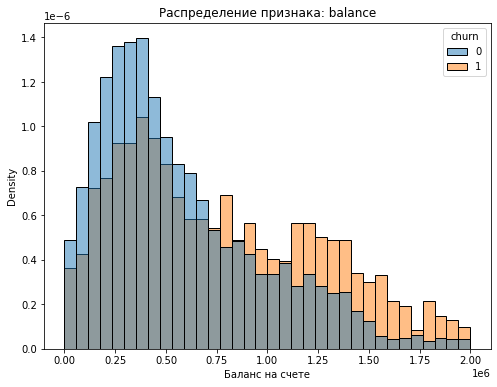

In [275]:
data_balance = data.query('balance < 2000000')

plt.figure(figsize=(8, 6))
sns.histplot(data_balance,x='balance', hue='churn',stat="density", common_norm=False)
plt.xlabel('Баланс на счете')
plt.title('Распределение признака: balance')
plt.show()

Достаточно высокий уровень оттока наблюдается у клиентов с балансом на счете от 750 тыс до 2 млн.

#### Распределение gender

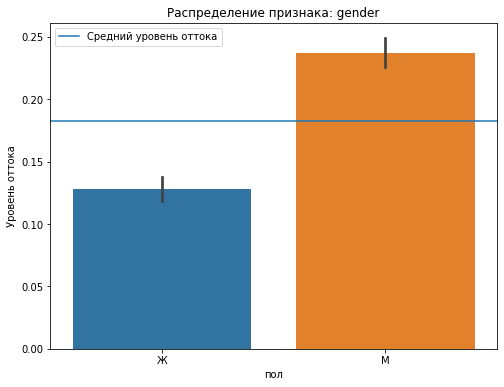

In [276]:
plt.figure(figsize=(8, 6))
sns.barplot(data=data, x='gender', y='churn')
plt.axhline(total_churn_level, label='Средний уровень оттока')
plt.xlabel('пол')
plt.ylabel('Уровень оттока')
plt.legend()

plt.title('Распределение признака: gender')
plt.show()

Доля оттока у мужчин выше, чем у женщин и выше, чем средний уровень оттока по банку.

#### Распределение products

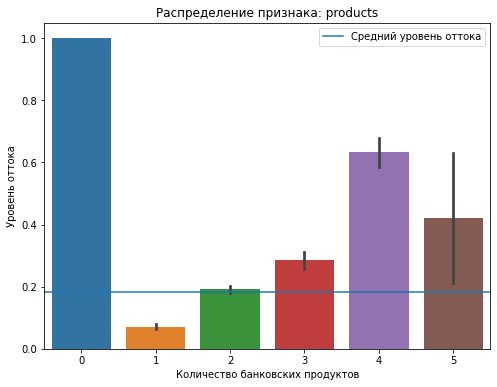

In [277]:
plt.figure(figsize=(8, 6))
sns.barplot(data=data, x='products', y='churn')
plt.axhline(total_churn_level, label='Средний уровень оттока')
plt.xlabel('Количество банковских продуктов')
plt.ylabel('Уровень оттока')
plt.legend()

plt.title('Распределение признака: products')
plt.show()

Можно заметить, что у клиентов, у которых нет банковских продуктов на 100% попадают в отток. Рассмотрим подробнее количество таких клиентов.

In [278]:
# считаем клиентов без банковских продуктов
data.query('products == 0')['products'].count()

1

В данных всего оди клиент, у которого нет банковских продуктов, именно поэтому в отток попало 100% клиентов.

Уровень оттока у клиентов, имеющих более двух банковских продуктов выше, чем по банку в целом.

#### Распределение credit_card

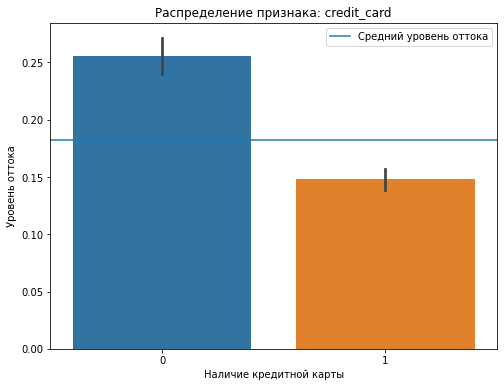

In [279]:
plt.figure(figsize=(8, 6))
sns.barplot(data=data, x='credit_card', y='churn')
plt.axhline(total_churn_level, label='Средний уровень оттока')
plt.xlabel('Наличие кредитной карты')
plt.ylabel('Уровень оттока')
plt.legend()

plt.title('Распределение признака: credit_card')
plt.show()

Клиенты, у котрых нет кредитных карт чаще уходят из банка, чем клиенты у которых они есть.

#### Распределение last_activity

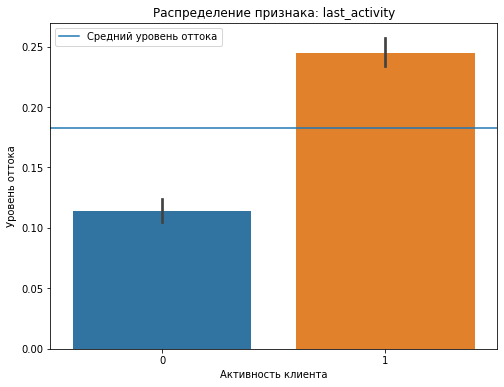

In [280]:
plt.figure(figsize=(8, 6))
sns.barplot(data=data, x='last_activity', y='churn')
plt.axhline(total_churn_level, label='Средний уровень оттока')
plt.xlabel('Активность клиента')
plt.ylabel('Уровень оттока')
plt.legend()

plt.title('Распределение признака: last_activity')
plt.show()

Доля оттока у активных клиентов выше, чем у неактивных и выше значения по банку в целом.

#### Распределение EST_SALARY

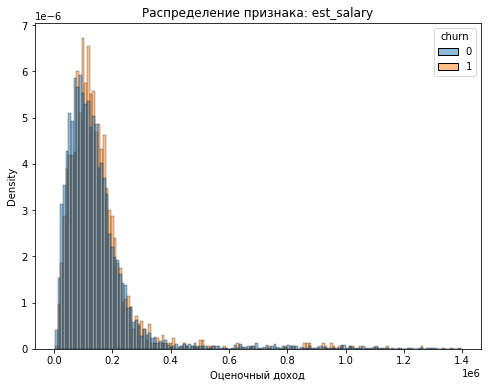

In [281]:
plt.figure(figsize=(8, 6))
sns.histplot(data,x='est_salary', hue='churn',stat="density", common_norm=False)
plt.xlabel('Оценочный доход')
plt.title('Распределение признака: est_salary')
plt.show()

Как в случае с признаком balance, необходимо сделать срез данных из-за аномальных значений.

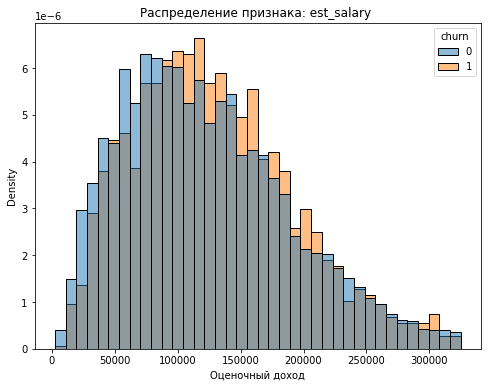

In [282]:
data_balance = data.query('est_salary < 325000')

plt.figure(figsize=(8, 6))
sns.histplot(data_balance,x='est_salary', hue='churn',stat="density", common_norm=False)
plt.xlabel('Оценочный доход')
plt.title('Распределение признака: est_salary ')
plt.show()

Достаточно высокий уровень оттока наблюдается у клиентов с оценочным доходом от 100 до 140 тыс., 160-170 тыс., 190-210 тыс. и 300-10 тыс.

### Корреляционный анализ признака churn с другими признаками ***

Так как в данных есть и непрерывные, и дискретные значения, воспользуемся корреляцией Phi_K.

In [283]:
# с помощью корреляции Phi_K рассмотрим, что влияет на факт оттока
phik = data.drop(['userid', 'balance_na', 'age_na'], axis=1).phik_matrix(interval_cols=['score', 'age', 'balance', 'est_salary'])

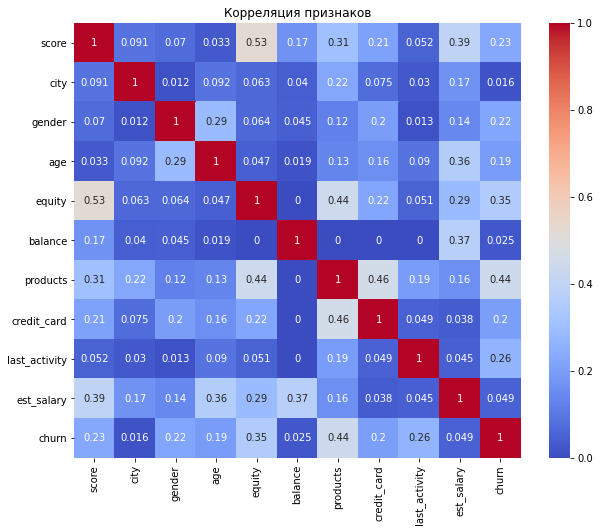

In [284]:
plt.figure(figsize=(10, 8))
sns.heatmap(phik,annot=True, cmap='coolwarm')
plt.title('Корреляция признаков')
plt.show()

Слабая корреляция (0.10-0.30) наблюдается между оттоком и баллами кредитного скоринга, пола, возраста, факта наличия кредитной карты и активностью клиента.

Умеренная корреляция (0.30-0.50) наблюдается между оттоком и количеством баллов собственности, количеством банковских продуктов.

С остальными признаками наблюдается очень слабая корреляция (до 0.10) - это признаки город, баланс на счете, оценочный доход.

Помимо самих коэффициентов корреляции необходимо рассмотреть значисость корреляции, так как даже при досточно высоких коэффициентах корреляции их значимость может быть низкой и наоборот.

In [285]:
# построим матрицу значимости коэффициентов корреляции
data.drop(['userid', 'balance_na', 'age_na'], axis=1).significance_matrix(interval_cols=['score', 'age', 'balance', 'est_salary'])

,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn
score,198.327572,5.901347,4.200093,0.765941,54.499473,5.977095,35.999289,17.744801,2.717724,33.522273,18.225702
city,5.901347,136.905538,1.624411,5.689056,3.392425,2.440852,12.676232,12.059214,4.685559,14.766308,2.390364
gender,4.200093,1.624411,117.405173,22.013741,3.619367,2.502939,8.108529,12.549105,0.920924,10.028667,14.184934
age,0.765941,5.689056,22.013741,194.353273,1.939321,2.047204,9.824535,11.004242,5.707473,32.832586,14.395314
equity,54.499473,3.392425,3.619367,1.939321,189.416129,0.538445,53.925837,16.382166,2.668577,23.948587,28.224699
balance,5.977095,2.440852,2.502939,2.047204,0.538445,17.461978,0.498781,0.106061,0.001347,9.706475,1.169458
products,35.999289,12.676232,8.108529,9.824535,53.925837,0.498781,147.683550,33.407345,13.666456,16.478126,29.436164
credit_card,17.744801,12.059214,12.549105,11.004242,16.382166,0.106061,33.407345,111.628335,3.097714,1.909263,12.649959
last_activity,2.717724,4.685559,0.920924,5.707473,2.668577,0.001347,13.666456,3.097714,117.318526,2.208125,17.095519
est_salary,33.522273,14.766308,10.028667,32.832586,23.948587,9.706475,16.478126,1.909263,2.208125,135.802022,2.741387


В соответствии с матрицей значимости можно сказать, что слабая и умеренная корреляции, установленные выше, являются значимыми.

### Портрет клиентов в разрезе оттока

Мы установили, что на отток в большей степени влияют следующие признаки: кол-во баллов собственности, кол-во банковских продуктов, кол-во баллов кредитного скоринга, пол, возраст, факт наличия кредитной карты и активность клиента.

На основании полученных данных составим портреты клиентов в разрезе оттока

In [286]:
# сформируем сводную таблицу со средними значениями показателей в разрезе оттока
data_portrait = data.pivot_table(index='churn', 
                                 values=[ 'age', 'score', 'products', 'equity', 'credit_card', 'last_activity', 
                                        'balance', 'est_salary'],
                                 aggfunc={ 'age':'mean', 'score':'mean', 'products':'median',
                                          'equity':'median', 'credit_card':'mean', 'last_activity':'mean',
                                         'balance':'mean', 'est_salary':'mean'})

In [287]:
# посчитаем относителюную разницу между значениями показателей отточных клиентов и клиентов, не попавших в отток
data_dif = round((data_portrait.loc[1] / data_portrait.loc[0] - 1), 2)

# объеденим полученные разницы со сводной таблицей
data_portrait = data_portrait.append(data_dif, ignore_index=True, sort=False)
data_portrait.index = ['Не отток', 'Отток', 'Относительная разница'] # изменим наименования столбцов

In [288]:
# посчитаем моду по полу отточных и не отточных клиентов
mode_gender_0 = mode(data.query('churn == 0')['gender'])
mode_gender_1 = mode(data.query('churn == 1')['gender'])

#посчитаем моду по городу отточных и не отточных клиентов
mode_city_0 = mode(data.query('churn == 0')['city'])
mode_city_1 = mode(data.query('churn == 1')['city'])

# создадим series с полученными значениями
data_mode_gender = {'Не отток':mode_gender_0, 'Отток':mode_gender_1, 'Относительная разница':'-'}
s1 = pd.Series(data=data_mode_gender)
s1.name = 'mode_gender'

data_mode_city = {'Не отток':mode_city_0, 'Отток':mode_city_1, 'Относительная разница':'-'}
s2 = pd.Series(data=data_mode_city)
s2.name = 'mode_city'

# объединими series с таблицей и транспонируем таблицу
data_portrait = pd.merge(data_portrait, s1, left_index=True, right_index=True)
data_portrait = pd.merge(data_portrait, s2, left_index=True, right_index=True).transpose()


#поменяем наименования строк
data_portrait.index = ['Средний возраст', 'Средний баланс на счете', 'Доля клиентов, имеющих кредитную карту','Кол-во баллов собственности',
                        'Средний оцененный доход', 'Доля активных клиентов', 'Среднее кол-во банковских продуктов', 
                        'Среднее число баллов кредитного скоринга', 'Мода по полу', 'Мода по городу']

data_portrait

,Не отток,Отток,Относительная разница
Средний возраст,43.020846,41.450247,-0.04
Средний баланс на счете,733031.630149,1134458.209291,0.55
"Доля клиентов, имеющих кредитную карту",0.70889,0.551402,-0.22
Кол-во баллов собственности,3.0,4.0,0.33
Средний оцененный доход,147674.637881,148289.702221,0.0
Доля активных клиентов,0.482894,0.702034,0.45
Среднее кол-во банковских продуктов,2.0,2.0,0.0
Среднее число баллов кредитного скоринга,845.396199,863.416163,0.02
Мода по полу,Ж,М,-
Мода по городу,Ярославль,Ярославль,-


Согласно полученным данным, можно сделать следующие выводы:
1. средний возраст отточных клиентов на 4% меньше, чем у не отточных клиентов
2. Средний баланс на счете отточных клиентов на 55% выше
3. Доля клиентов, имеющих кредитку у оттока на 22% ниже, чем у не отточных
4. У отточных клиентов на 33% выше значения баллов собственности, чем у не отточных
5. Средний оцененный доход практически не отличается
6. Доля актвных клиентов также выше у отточных клиентов - на 45%
7. Среднее кол-во банковских продуктов на 35% выше у отточных клиентов
8. Среднее кол-во баллов кредитного скоринга отличается всего на 2 %
9. В отток чаще попадпли мужчины

***Таким образом, можно сформировать следующие портреты:***
- ***Отточный клиент***: мужчина, средний возраст около 41 года, со средним балансом около 1134 тыс., с 4 баллами собственности, более активные, чем не отточные клиенты, реже имеют кредитную карту, среднее число баллов кредитного скоринга - 863


- ***Не отточный клиент***: женщина, средний возраст около 43 лет, со средним балансом около 733 тыс., с 3 баллами собственности, менее активные, чем отточные клиенты, чаще имеют кредитную карту, среднее число баллов кредитного скоринга - 845

## Проверка статистических гипотез


- H0 формулируют так, чтобы использовать знак равенства.
- Альтернативная гипотеза H1 формулируется на основании нулевой гипотезы. Это утверждение, которое принимается верным, если отвергается H0

Для проверки гипотез значение alpha примем равным 0.5. Для каждой гипотезы проверим возможно ли использовать метод проверки ttest_ind.

### Гипотеза: доходы отточных клиентов и клиентов, которые не ушли, различаются

H0 - доходы отточных клиентов и клиентов, которые не ушли, различаются РАВНЫ

H1 - доходы отточных клиентов и клиентов, которые не ушли, различаются ОТЛИЧАЮТСЯ

Сравниваемые совокупности являются независимыми, поэтому мы можем использовать ttest_ind. Сравним размеры выборок, для того чтобы выбрать правильное значение параметра equal_var, кроме того, на этапе EDA было выявлено, что у показателя est_salary достаточно много аномальных значений, влияющих на размер средней, поэтому ограничим доход 325 тыс.

In [289]:
# делаем срез данных по полю est_salary
data_hyp = data.query('est_salary < 325000')

In [290]:
print('Размер совокопуности для отточных клиентов:', len(data_hyp.query('churn == 1')['est_salary']))
print('Размер совокопуности для не отточных клиентов:', len(data_hyp.query('churn == 0')['est_salary']))

Размер совокопуности для отточных клиентов: 1741
Размер совокопуности для не отточных клиентов: 7761


Размеры выборок достаточно сильно различаются, поэтому примем значение equal_var равным False.

In [291]:
alpha = 0.05 # задаем уровень статистической значимости

# рассчитываем p-value
results = st.ttest_ind(data_hyp.query('churn == 1')['est_salary'], data_hyp.query('churn == 0')['est_salary'], equal_var=False)

print('p-значение:', results.pvalue) #выводим значение p-value

# сравниваем полученное p-value с уровнем значимости
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

p-значение: 0.00012640759056403754
Отвергаем нулевую гипотезу


По итогам проверки гипотезы мы отвергаем нулевую гипотезу, то есть средние доходы отточных и не отточных клиентов отличаются. На этапе EDA были построены гистограммы распределения данного показателя в разрезе оттока, на которых было видно, что у отточных клиентов гистограмма была сдвинута в сторону бОльших значений.

### Гипотеза: количество банковских продуктов у отточных клиентов больше, чем у тех, кто не ушел

На графике распределения показателя products было видно, что доля отточных клиентов больше у болле высоких значениях показателя. Сформулируем на основании этого наблюдения гипотезу и проверим ее.  


H0 - кол-во банковских продуктов у отточных клиентов и клиентов, которые не ушли, различаются РАВНЫ

H1 - кол-во банковских продуктов у отточных клиентов БОЛЬШЕ, чем у клиентов, которые не ушли



Сравниваемые совокупности являются независимыми, поэтому мы можем использовать ttest_ind. Сравним размеры выборок, для того чтобы выбрать правильное значение параметра equal_var.

In [292]:
print('Размер совокопуности для отточных клиентов:', len(data.query('churn == 1')['products']))
print('Размер совокопуности для не отточных клиентов:', len(data.query('churn == 0')['products']))

Размер совокопуности для отточных клиентов: 1819
Размер совокопуности для не отточных клиентов: 8155


Размеры выборок достаточно сильно различаются, поэтому примем значение equal_var равным False.

In [293]:
# рассчитываем p-value
results = st.ttest_ind(data.query('churn == 1')['products'], data.query('churn == 0')['products'], equal_var=False, alternative='greater')

print('p-значение:', results.pvalue) #выводим значение p-value

# сравниваем полученное p-value с уровнем значимости
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

p-значение: 3.7687321686006366e-138
Отвергаем нулевую гипотезу


По итогам проверки данной гипотезы мы отвергаем H0, это означает, что у отточных клиентов действительно в среднем больше банковских продуктов.

### Гипотеза: количество баллов собственности у отточных клиентов больше, чем у тех, кто не ушел

На графике распределения показателя equity можно заметить, что с ростом значений данного показателя увеличивается доля отточных клиентов. Сформулируем на основании этого наблюдения гипотезу и проверим ее.


H0 - кол-во баллов собственности у отточных клиентов и клиентов, которые не ушли, различаются РАВНЫ

H1 - кол-во баллов собственности у отточных клиентов БОЛЬШЕ, чем у клиентов, которые не ушли



Сравниваемые совокупности являются независимыми, поэтому мы можем использовать ttest_ind. Сравним размеры выборок, для того чтобы выбрать правильное значение параметра equal_var.

In [294]:
print('Размер совокопуности для отточных клиентов:', len(data.query('churn == 1')['equity']))
print('Размер совокопуности для не отточных клиентов:', len(data.query('churn == 0')['equity']))

Размер совокопуности для отточных клиентов: 1819
Размер совокопуности для не отточных клиентов: 8155


Размеры выборок достаточно сильно различаются, поэтому примем значение equal_var равным False.

In [295]:
# рассчитываем p-value
results = st.ttest_ind(data.query('churn == 1')['equity'], data.query('churn == 0')['equity'], equal_var=False, alternative='greater')

print('p-значение:', results.pvalue) #выводим значение p-value

# сравниваем полученное p-value с уровнем значимости
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

p-значение: 1.0052199914102907e-196
Отвергаем нулевую гипотезу


По итогам проверки гипотезы мы отвергаем H0, то есть у отточных клиентов баллы собственности выше, чем у не отточных.

## Промежуточные выводы

На этапах исследовательского анализа данных, корреляционного анализа и проверке статистических гипотез было установлено следующее:
1. Среди значений признаков balance и est_salary есть множество выбросов - аномально больших значений.
2. Средний уровень оттока по банку в целом составляет 18,2%
3. Признаки в разрезе оттока:
   - Наибольшее значение оттока можно увидеть на промежутке от 830 до 910 баллов кредитного скоринга
   - Уровень оттока в Ярославле и Ростове выше, чем средний уровень оттока по банку
   - Высокий уровень оттока наблюдается у клиентов в возрасте 26-34 года и 50-60 лет
   - У клиентов с количеством баллов собственности выше 2 уровень оттока выше, чем в среднем по банку
   - Достаточно высокий уровень оттока наблюдается у клиентов с балансом на счете от 750 тыс до 2 млн.
   - Доля оттока у мужчин выше, чем у женщин и выше, чем средний уровень оттока по банку
   - Уровень оттока у клиентов, имеющих более двух банковских продуктов выше, чем по банку в целом
   - Клиенты, у котрых нет кредитных карт чаще уходят из банка
   - Доля оттока у активных клиентов выше, чем у неактивных и выше значения по банку в целом
   - Достаточно высокий уровень оттока наблюдается у клиентов с оценочным доходом от 100 до 140 тыс., 160-170 тыс., 190-210 тыс. и 300-10 тыс
   
   
4. Корреляция: 
   - Слабая корреляция (0.10-0.30) наблюдается между оттоком и баллами кредитного скоринга, пола, возраста, факта наличия кредитной карты и активностью клиента
   - Умеренная корреляция (0.30-0.50) наблюдается между оттоком и количеством баллов собственности, количеством банковских продуктов
   
   
5. Проверка статистических гипотез:
   - Средние доходы отточных и не отточных клиентов отличаются
   - У отточных клиентов действительно в среднем больше банковских продуктов
   - У отточных клиентов баллы собственности выше, чем у не отточных
   
   
Таким образом, можно выделить признаки, влиющие на отток, а именно: кол-во баллов собственности, кол-во банковских продуктов, пол, факта наличия кредитной карты и активность клиента

## Сегментация клиентов

### Комбинации признаков оттока

С помощью срезов вычислим уровень оттока в группах, собранных по различным признакам. Доля оттока должна быть выше 18,2%
Интервалы признаков, соответствующие отточным клиентам были описаны выше.

Рассмотрим признаки:
- количество баллов собственности > 2
- количество банковских продуктов > 1
- пол - м

In [296]:
display(data.query('(equity > 2) and (products > 1 ) and (gender == "М")')['churn'].mean())

display(data.query('(equity > 2) and (products > 1 ) and (balance > 750000) and (balance < 2000000)')['churn'].mean())

0.38006230529595014

0.35163616195230174

Рассмотрим признаки:
- количество баллов собственности > 2
- количество банковских продуктов > 1
- баланс на счете от 750 тыс. до 2 млн.

In [297]:
display(data.query('(equity > 2) and (products > 1 ) and (balance > 750000) and (balance < 2000000)')['churn'].mean())

0.35163616195230174

Рассмотрим признаки:
- количество баллов собственности > 2
- количество банковских продуктов > 1
- количество баллов кредитного скоринга от 830 до 910

In [298]:
display(data.query('(equity > 2) and (products > 1 ) and (score > 830) and (score < 910)')['churn'].mean())

0.34491746307558646

Рассмотрим признаки:
- количество баллов собственности > 2
- количество банковских продуктов > 1
- клиент активный

In [299]:
display(data.query('(equity > 2) and (products > 1 ) and (last_activity == 1)')['churn'].mean())

0.3857374392220421

Рассмотрим признаки:
- количество баллов собственности > 2
- количество банковских продуктов > 1
- возраст от 26 до 34 или от 50 до 60

In [300]:
display(data.query('(equity > 2) and (products > 1 ) and (age > 50) and (age < 60)')['churn'].mean())

display(data.query('(equity > 2) and (products > 1 ) and (age > 26) and (age < 34)')['churn'].mean())

0.40714285714285714

0.3365180467091295

Рассмотрим признаки:
- количество баллов собственности > 2
- количество банковских продуктов > 1
- оценочный доход от 100 тыс. до 140 тыс., от 160 тыс. до 170 тыс. или от 190 тыс. до 210 тыс.

In [301]:
display(data.query('(equity > 2) and (products == 1 ) and (est_salary > 100000) and (est_salary < 1400000)')['churn'].mean())

display(data.query('(equity > 2) and (products > 1 ) and (est_salary > 100000) and (est_salary < 1400000)')['churn'].mean())

display(data.query('(equity > 2) and (products == 1 ) and (est_salary > 160000) and (est_salary < 1700000)')['churn'].mean())

display(data.query('(equity > 2) and (products > 1 ) and (est_salary > 160000) and (est_salary < 1700000)')['churn'].mean())

display(data.query('(equity > 2) and (products == 1 ) and (est_salary > 190000) and (est_salary < 2100000)')['churn'].mean())

display(data.query('(equity > 2) and (products > 1 ) and (est_salary > 190000) and (est_salary < 2100000)')['churn'].mean())

0.18811881188118812

0.34831460674157305

0.16666666666666666

0.40531276778063413

0.18333333333333332

0.4289772727272727

Рассмотрим признаки:
- кол-во баллов кредитного скоринга от 830 до 910
- пол мужской
- возраст 26-34 или 50-60

In [302]:
display(data.query('(score > 830) and (score < 910) and (gender == "М") and (age > 50) and (age < 60)')['churn'].mean())

display(data.query('(score > 830) and (score < 910) and (gender == "М") and (age > 26) and (age < 34)')['churn'].mean())

0.417910447761194

0.3403805496828753

Рассмотрим признаки:
- кол-во баллов кредитного скоринга от 830 до 910
- пол мужской
- количество баллов собственности больше 2

In [303]:
display(data.query('(score > 830) and (score < 910) and (gender == "М") and (equity > 2)')['churn'].mean())

0.4205748865355522

### Проверка размерности групп с высоким уровнем оттока

Посчитаем количество отточных клиентов в группах с высоким уровнем оттока. Число отточных клиентов должно быть больше 500.

Проверим в первую очередь шруппы с уровнем оттока более 40%

In [304]:
display(data.query('(churn ==1) and (equity > 2) and (products == 0 ) and (age > 50) and (age < 60)')['churn'].count())

display(data.query('(churn ==1) and(equity > 2) and (products > 1 ) and (est_salary > 160000) and (est_salary < 1700000)')['churn'].count())

display(data.query('(churn ==1) and(equity > 2) and (products > 1 ) and (est_salary > 190000) and (est_salary < 2100000)')['churn'].count())

display(data.query('(churn ==1) and(score > 830) and (score < 910) and (gender == "М") and (age > 50) and (age < 60)')['churn'].count())

0

473

302

112

Число клиентов, попавших в отток, меньше 500.

Проверим группы с долей оттока более 30%.

In [305]:
display(data.query('(churn == 1) and (equity > 2) and (products > 1 ) and (gender == "М")')['churn'].count())

display(data.query('(churn == 1) and (equity > 2) and (products > 1 ) and (balance > 750000) and (balance < 2000000)')['churn'].count())

display(data.query('(churn == 1) and (equity > 2) and (products > 1 ) and (score > 830) and (score < 910)')['churn'].count())

display(data.query('(churn == 1) and (equity > 2) and (products > 1 ) and (last_activity == 1)')['churn'].count())

display(data.query('(churn == 1) and (equity > 2) and (products > 1 ) and (age > 26) and (age < 34)')['churn'].count())

display(data.query('(churn == 1) and (score > 830) and (score < 910) and (gender == "М") and (age > 26) and (age < 34)')['churn'].count())

854

634

794

952

317

161

В четырех группах число отточных клиентов превышает 500. Проверим общее число клиентов в группах.

In [306]:
display(data.query('(equity > 2) and (products > 1 ) and (gender == "М")')['churn'].count())

display(data.query('(equity > 2) and (products > 1 ) and (balance > 750000) and (balance < 2000000)')['churn'].count())

display(data.query('(equity > 2) and (products > 1 ) and (score > 830) and (score < 910)')['churn'].count())

display(data.query('(equity > 2) and (products > 1 ) and (last_activity == 1)')['churn'].count())

2247

1803

2302

2468

В каждой группе достаточное количество клиентов, таким образом, можно выделить 4 сегмента отточных клиентов:

1. Мужчины с баллами собственности больше 2 и имеющие более 2х банковских продуктов - 2247 клиентов из них 854 отточных. Доля оттока - 38%
2. Клиенты с балансом на карте от 750тыс. до 2 млн., высокими баллами собственности (больше 2) и несколькими банковскими продуктами - 1803 клиента из них 634 отточных. Доля оттока - 35,1%
3. Клиенты с баллами кредитного скоринга от 830 до 910, высокими баллами собственности (больше 2) и несколькими банковскими продуктами - 2302 клиента из них 794 отточных. Доля оттока 34,5%
4. Активные клиенты высокими баллами собственности (больше 2) и несколькими банковскими продуктами - 2468 клиентов из них 952 отточных. Доля оттока 38,6%

## Приоритизация сегментов

Так как у отдела маркетинга нет автоматизированных систем, необходимо приоритизировать полученные сегменты.

Логичнее всего приоритизировать сегменты на основании числа отточных клиентов, так как это даст возможность охватить большее число клиентов и, соответственно, в большей степени сократить отток.

Самое большое число отточных клиентов наблюдается в 4 сегменте - 952 отточных клиента - однако, разработать конкретную программу по работе с такими клиентами достаточно сложно, поэтому более эффективно будет начать работу с 1 сегмента, в котором 854 отточных клиента. Затем необходимо рассмотреть клиентов из 3 сегмента с 794 отточными клиентами, потом из 2 сегмента - 634 отточных клиента, и в конце работать с 4 сегментом.

## Вывод и рекомендации

Для анализа оттока клиентов банком были предоставлены следующие данные о клиентах: баллы кредитного скоринга, город, возраст, баллы собственности, баланс на счете, пол,кол-во банковских продуктов, наличие кредитной карты, активность клиента, оценочный доход. Полученные данные были предобработаны, а именно приведены к единому стилю, обработаны дубликаты и пропуски.

На этапе исследовательского анализа данных были выявлены признаки с аномальными значениями - баланс на счете и оценочный доход. Также был посчитан общий уровень оттока по банку, равный 18,2%. В результате анализа признаков в разрезе оттока, корреляционного анализа и проверки статистических гипотез было выявлено следующее:
   - Наибольшее значение оттока можно увидеть на промежутке от 830 до 910 баллов кредитного скоринга
   - Уровень оттока в Ярославле и Ростове выше, чем средний уровень оттока по банку
   - Высокий уровень оттока наблюдается у клиентов в возрасте 26-34 года и 50-60 лет
   - У клиентов с количеством баллов собственности выше 2 уровень оттока выше, чем в среднем по банку
   - Достаточно высокий уровень оттока наблюдается у клиентов с балансом на счете от 750 тыс до 2 млн.
   - Доля оттока у мужчин выше, чем у женщин и выше, чем средний уровень оттока по банку
   - Уровень оттока у клиентов, имеющих более двух банковских продуктов выше, чем по банку в целом
   - Клиенты, у котрых нет кредитных карт чаще уходят из банка
   - Доля оттока у активных клиентов выше, чем у неактивных и выше значения по банку в целом
   - Достаточно высокий уровень оттока наблюдается у клиентов с оценочным доходом от 100 до 140 тыс., 160-170 тыс., 190-210 тыс. и 300-10 тыс
   
   - Слабая корреляция (0.10-0.30) наблюдается между оттоком и баллами кредитного скоринга, пола, возраста, факта наличия кредитной карты и активностью клиента
   - Умеренная корреляция (0.30-0.50) наблюдается между оттоком и количеством баллов собственности, количеством банковских продуктов
   
   - Средние доходы отточных и не отточных клиентов отличаются
   - У отточных клиентов действительно в среднем больше банковских продуктов
   - У отточных клиентов баллы собственности выше, чем у не отточных
   
   
В соответствии с результатами анализа были сформированы и приоритизированны сегменты (указаны в порядке важности):
1. Мужчины с баллами собственности больше 2 и имеющие более 2х банковских продуктов - 2247 клиентов из них 854 отточных
2. Клиенты с баллами кредитного скоринга от 830 до 910, высокими баллами собственности (больше 2) и несколькими банковскими продуктами - 2302 клиента из них 794 отточных
3. Клиенты с балансом на карте от 750тыс. до 2 млн., высокими баллами собственности (больше 2) и несколькими банковскими продуктами - 1803 клиента из них 634 отточных
4. Активные клиенты высокими баллами собственности (больше 2) и несколькими банковскими продуктами - 2468 клиентов из них 952 отточных


Так как сегменты в целом имеют схожие черты, можно предложить следующие общие рекомендации: 
- высокие баллы кредитного скоринга и высокие баллы собственности говорят о высокой платежеспособности клиентов, таким клиентам можно предложить персональные условия различных продуктов, например, персональные ставки по кредитным картам
- клиентам с высоким балансом на карте можно также предложить персональные условия, но, например, уже по депозитам или по уникальным банковским продуктам (брокерские счета, драг металлы)
- клиентам с несколькими объектами имущества целесообразно предложить персональные условия страхования имущества
- кроме того, среди отточных клиентов большинство - это мужчины, то есть можно формировать партнерские программы, например, со спортивными залами, строительными магазинами, автосалонами и тп. По программам могут предоставляться скидки или особые условия обслуживания